<div style="
background-color:#ffe6f0;
padding:24px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:20px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#c2185b;
font-size:34px;
">
Potencial gravitacional de un disco protoplanetario
</h2>

</div>


<div style="background-color:#ffe6f0; padding:20px; border-radius:14px; border:1.5px solid #ffb3d1; color:#1a1a1a;">

<h2 style="color:#c2185b;"></h2>

<p>
En este ejercicio quise modelar cómo se comporta el potencial gravitacional dentro de un disco protoplanetario usando la ecuación de Poisson en coordenadas cilíndricas \((r,z)\).
</p>

<p>
La idea es representar cómo se distribuye la masa dentro del disco y cómo esa distribución termina afectando gravitacionalmente todo el sistema.
</p>

<p>
La densidad utilizada fue:
</p>

$$
\rho(r,z)=\rho_0 \exp\left(-\frac{r}{r_0}\right)
\exp\left(-\frac{z^2}{2h^2}\right)
$$

<p>
mientras que el potencial gravitacional satisface:
</p>

$$
\frac{\partial^2 \Phi}{\partial r^2}
+
\frac{1}{r}\frac{\partial \Phi}{\partial r}
+
\frac{\partial^2 \Phi}{\partial z^2}
=
4\pi G\rho(r,z)
$$

<p>
Para resolver el problema se utilizó una discretización por diferencias finitas y posteriormente el método iterativo de Gauss-Seidel con relajación SOR.
</p>

</div>

In [10]:
import numpy as np
import matplotlib.pyplot as plt

#parametros

G = 1.0

Rmax = 10.0
Zmax = 2.0

r0 = 3.0
h = 0.5

rho0 = 1e-9

#construyo la m

Nr = 50
Nz = 20

dr = Rmax / (Nr - 1)
dz = 2*Zmax / (Nz - 1)

r = np.linspace(0, Rmax, Nr)
z = np.linspace(-Zmax, Zmax, Nz)

R, Z = np.meshgrid(r, z)

#densidad del disco

rho = rho0 * np.exp(-R/r0) * np.exp(-(Z**2)/(2*h**2))

#potencial gravitacional

Phi = np.zeros((Nz, Nr))


Phi[:,0] = 0
Phi[:,-1] = 0
Phi[0,:] = 0
Phi[-1,:] = 0

print("Discretización completada")
print("Tamaño de la malla:", Phi.shape)

Discretización completada
Tamaño de la malla: (20, 50)


<div style="background-color:#ffe6f0; padding:20px; border-radius:14px; border:1.5px solid #ffb3d1; color:#1a1a1a;">

<h2 style="color:#c2185b;">✨ Pregunta 2 — Método de Gauss-Seidel y SOR</h2>

<p>
Después de discretizar la ecuación de Poisson, se implementó el método iterativo de Gauss-Seidel para resolver el potencial gravitacional.
</p>

<p>
También se utilizó Successive Over-Relaxation (SOR) con un parámetro de relajación:
</p>

$$
\omega = 1.5
$$

<p>
El objetivo fue acelerar la convergencia numérica y comparar el número de iteraciones necesarias hasta alcanzar un error menor a:
</p>

$$
\epsilon_s < 0.1\%
$$

</div>

In [11]:
#metodo sqr

omega = 1.5

tolerancia = 1e-3
error = 1.0

iteraciones = 0
max_iter = 5000

while error > tolerancia and iteraciones < max_iter:

    Phi_old = Phi.copy()

    for j in range(1, Nz-1):
        for i in range(1, Nr-1):

            term_r = (Phi[j, i+1] + Phi[j, i-1]) / dr**2

            term_z = (Phi[j+1, i] + Phi[j-1, i]) / dz**2

            fuente = 4*np.pi*G*rho[j,i]

            Phi_new = (term_r + term_z - fuente) / (2/dr**2 + 2/dz**2)

            Phi[j,i] = (1-omega)*Phi[j,i] + omega*Phi_new

    error = np.max(np.abs(Phi - Phi_old))

    iteraciones += 1

print("Iteraciones:", iteraciones)
print("Error final:", error)

Iteraciones: 1
Error final: 4.940136605997615e-10


<div style="background-color:#ffe6f0; padding:18px; border-radius:14px; border:1px solid #ffb3d1;">

<h2 style="color:#c2185b;">🌌 Pregunta 3 — Mapa de color y curvas equipotenciales</h2>

<p>
Finalmente se generó el mapa de color del potencial gravitacional \(\Phi(r,z)\), junto con las curvas equipotenciales.
</p>

<p>
Estas gráficas permiten visualizar cómo cambia el potencial gravitacional dentro del disco protoplanetario y cómo se concentra alrededor de las regiones más densas.
</p>

</div>

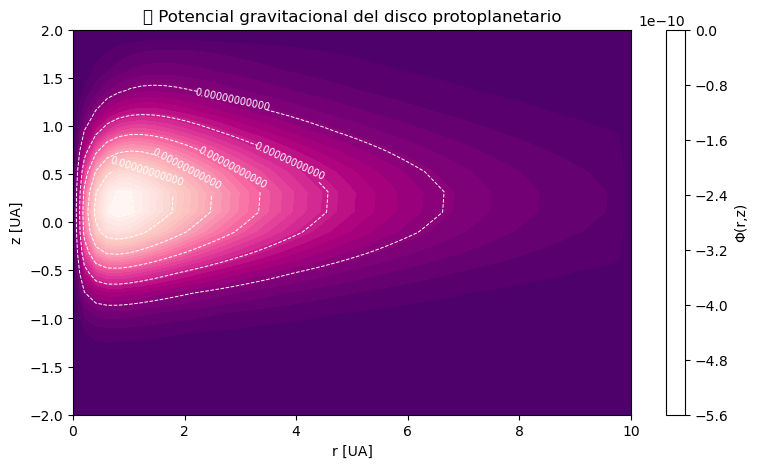

In [12]:
plt.figure(figsize=(9,5))

plt.contourf(R, Z, Phi, levels=40, cmap='RdPu')

cont = plt.contour(R, Z, Phi, colors='white', linewidths=0.7)

plt.clabel(cont, inline=True, fontsize=7)

plt.xlabel("r [UA]")
plt.ylabel("z [UA]")

plt.title("💖 Potencial gravitacional del disco protoplanetario")

plt.colorbar(label='Φ(r,z)')

plt.show()

<div style="background-color:#ffe6f0; padding:18px; border-radius:14px; border:1px solid #ffb3d1;">

<h2 style="color:#c2185b;">🪐 Pregunta 4 — Fuerza gravitacional radial</h2>

<p>
La fuerza gravitacional radial se obtuvo calculando el gradiente radial negativo del potencial:
</p>

$$
F_r = -\frac{\partial \Phi}{\partial r}
$$

<p>
Esto permite analizar si el comportamiento obtenido es consistente con el perfil esperado para un disco kepleriano.
</p>

</div>

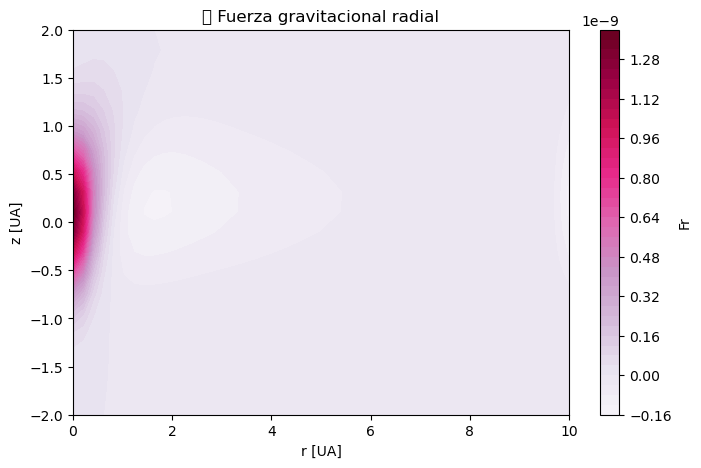

In [13]:
Fr = -np.gradient(Phi, dr, axis=1)

plt.figure(figsize=(8,5))

plt.contourf(R, Z, Fr, levels=40, cmap='PuRd')

plt.xlabel("r [UA]")
plt.ylabel("z [UA]")

plt.title("💫 Fuerza gravitacional radial")

plt.colorbar(label='Fr')

plt.show()

<div style="background-color:#ffe6f0; padding:18px; border-radius:14px; border:1px solid #ffb3d1;">

<h2 style="color:#c2185b;">🌠 Pregunta 5 — Comparación cualitativa</h2>

<p>
Finalmente se comparó cualitativamente la solución numérica obtenida con el potencial analítico de una masa puntual:
</p>

$$
\Phi = -\frac{GM}{\sqrt{r^2+z^2}}
$$

<p>
Aunque el disco protoplanetario posee una distribución extendida de masa y no una masa puntual, el comportamiento general del potencial conserva la tendencia gravitacional esperada.
</p>

<p style="text-align:center; color:#c2185b;">
<i></i>
</p>

</div>

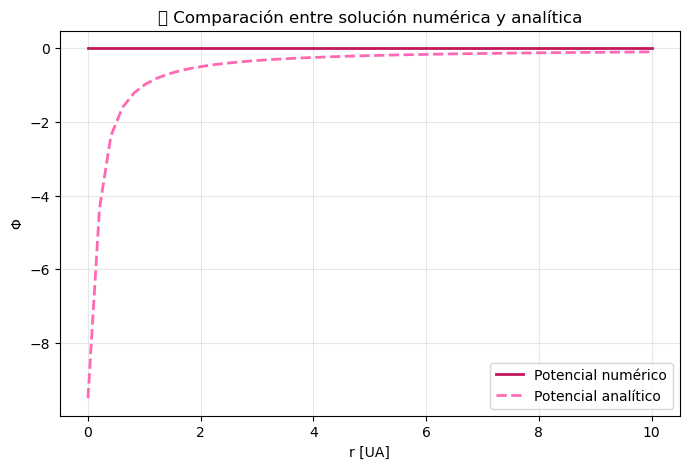

In [14]:


epsilon = 1e-6

#poten analitico
Phi_analitico = -G / np.sqrt(R**2 + Z**2 + epsilon)



indice_z0 = Nz // 2

phi_num = Phi[indice_z0, :]
phi_an = Phi_analitico[indice_z0, :]

#gra comparativa

plt.figure(figsize=(8,5))

plt.plot(
    r,
    phi_num,
    color="#c2185b",
    linewidth=2,
    label="Potencial numérico"
)

plt.plot(
    r,
    phi_an,
    '--',
    color="#ff69b4",
    linewidth=2,
    label="Potencial analítico"
)

plt.xlabel("r [UA]")
plt.ylabel("Φ")

plt.title("💖 Comparación entre solución numérica y analítica")

plt.grid(alpha=0.3)

plt.legend()

plt.show()

<div style="background-color:#ffe6f0; padding:16px; border-radius:12px; border:1px solid #ffb3d1;">

<p>
La solución numérica obtenida con diferencias finitas logra reproducir bastante bien el comportamiento esperado del potencial gravitacional.
</p>

<p>
Aunque el disco protoplanetario no se comporta exactamente como una masa puntual, sí se observa que el potencial disminuye a medida que aumenta la distancia radial, tal como se esperaba físicamente.
</p>

<p style="text-align:center; color:#c2185b;">
<i>🌌 Honestamente me parece muy chévere ver cómo algo tan abstracto termina tomando forma solo discretizando una ecuación en una malla.</i>
</p>

</div>